In [10]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import gymnasium as gym
from gymnasium.spaces import Dict, MultiDiscrete, Box
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.env_util import make_vec_env
import numpy as np
from scipy.signal import convolve2d
from typing import Literal
from src.config import (
    LAND_COVER_LABELS, PROTECTED_CLASSES,
    N_CLASSES, N_PIXELS_PER_CELL, SAMPLE_SIZE, GRID_KWARGS, SEED, data_dir, log_dir, model_dir, CENTER
) # ECONOMIC_VALUES
from src.utils import minmax_normalize, get_logger
import wandb
from wandb.integration.sb3 import WandbCallback

logger = get_logger(__name__)

# ── Mock ET cost per land-cover class (mm / year) ──────────────────────
# Higher values → more water consumption → higher environmental cost
ET_COST = {
    1:  100,   # Water        – minimal (surface evaporation counted elsewhere)
    2:  600,   # Trees        – moderate transpiration
    4:  100,   # Flooded      – similar to open water
    5:  850,   # Crops        – irrigation-heavy
    7:  200,   # Built Area   – low (impervious surface)
    8:  50,    # Bare Ground  – very low
    9:  0,     # Snow/Ice     – negligible
    10: 0,     # Clouds       – N/A
    11: 400,   # Rangeland    – moderate
}
ECONOMIC_VALUES = {
    1:  554,    # Water        – fisheries + ecosystem services
    2:  325,    # Trees/Forest – firewood, carbon, water regulation
    4:  554,    # Flooded/Wetlands – same as water/wetlands valuation
    5:  400,    # Crops        – rainfed maize midpoint ($300-$500)
    7:  2000,   # Built Area   – urban real-estate (constraint: very high)
    8:  25,     # Bare Ground  – minimal value
    9:  0,      # Snow/Ice     – no economic value
    10: 0,      # Clouds       – no economic value (masked)
    11: 75,     # Rangeland    – low-intensity grazing
}

norm_et_cost = minmax_normalize(ET_COST)
norm_eco_values = minmax_normalize(ECONOMIC_VALUES)

# Build dense arrays for vectorised reward computation
ECO_PER_CLASS = np.zeros(N_CLASSES, dtype=np.float32)
ET_PER_CLASS  = np.zeros(N_CLASSES, dtype=np.float32)
for _cls, _val in norm_eco_values.items():
    if _cls < N_CLASSES:
        ECO_PER_CLASS[_cls] = _val
for _cls, _val in norm_et_cost.items():
    if _cls < N_CLASSES:
        ET_PER_CLASS[_cls] = _val

# Modifiable (non-protected) land-cover classes
MODIFIABLE_CLASSES = sorted(set(range(N_CLASSES)) - PROTECTED_CLASSES)
N_MOD = len(MODIFIABLE_CLASSES)

print(f"All classes       : {list(LAND_COVER_LABELS.items())}")
print(f"Protected classes : {PROTECTED_CLASSES}")
print(f"Modifiable classes: {MODIFIABLE_CLASSES}  (n={N_MOD})")
print(f"Pixels per cell   : {N_PIXELS_PER_CELL}")
print(f"Grid size per ep  : {SAMPLE_SIZE}×{SAMPLE_SIZE}")

All classes       : [(1, 'Water'), (2, 'Trees'), (4, 'Flooded'), (5, 'Crops'), (7, 'Built Area'), (8, 'Bare Ground'), (9, 'Snow/Ice'), (10, 'Clouds'), (11, 'Rangeland')]
Protected classes : frozenset({1, 3, 4, 6, 9, 10})
Modifiable classes: [0, 2, 5, 7, 8, 11]  (n=6)
Pixels per cell   : 25
Grid size per ep  : 10×10


In [11]:
ECO_PER_CLASS

array([0.    , 0.277 , 0.1625, 0.    , 0.277 , 0.2   , 0.    , 1.    ,
       0.0125, 0.    , 0.    , 0.0375], dtype=float32)

In [12]:
ET_PER_CLASS

array([0.    , 0.1176, 0.7059, 0.    , 0.1176, 1.    , 0.    , 0.2353,
       0.0588, 0.    , 0.    , 0.4706], dtype=float32)

In [33]:
len(data['train_indices']), len(data['test_indices'])

(17, 8)

## Env Setup Demo

In [ ]:
def augment_data(data, size, seed, split='train_indices', do_augmentation=True, n_augment=10):
    if split == 'no_split':
        indices = np.concatenate((data['train_indices'], data['test_indices']), axis=0)
    else:
        indices = data[split]

    samples = np.stack([
        data['pixel_counts'][i[0]:i[0]+size, i[1]:i[1]+size]
        for i in indices
    ])
    rng = np.random.default_rng(seed)

    if do_augmentation:
        j = 0
        while j < n_augment:
            augmented = []
            for i in indices:
                sample = data['pixel_counts'][i[0]:i[0]+size, i[1]:i[1]+size]
                flat = sample.reshape(-1, N_CLASSES)
                rng.shuffle(flat)
                augmented.append(flat.reshape(size, size, N_CLASSES))

            samples = np.concatenate([samples, np.stack(augmented)]) 
            j += 1
    return samples

In [55]:
data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
samples = augment_data(data, 10, SEED, split='no_split')
samples.shape

(275, 10, 10, 12)

In [56]:
data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
samples = augment_data(data, 10, SEED, split='train_indices')
samples.shape

(187, 10, 10, 12)

In [46]:
data['train_indices'].shape

(17, 2)

In [47]:
data['test_indices'].shape

(8, 2)

In [35]:
from posixpath import split


class LandUseEnv(gym.Env):
    """
    RL Environment for land-use allocation optimization.

    State: A square grid where each cell has fractions of N_CLASSES land-cover types (normalized to [0,1])
    Action: Flattened action containing cell coordinates and delta changes for MODIFIABLE classes only
    Reward: Change in total value with spatial modifiers and ET penalty
    """
    metadata = {"render_modes": []}

    def __init__(self, size=10, max_steps=500, delta_boundary=1,
                 split: Literal['train_indices', 'test_indices', 'no_split'] = 'train_indices',
                 add_spatial_reward=True, lambda_cont=0.5, lambda_buf=2.0,
                 lambda_et=1.0, reward_scale=1.0, n_augment=10):
        """
        Args:
            size: Grid dimension (default 10x10 cells)
            max_steps: Maximum steps per episode
            delta_boundary: Maximum absolute change per land-use class (-delta_boundary to +delta_boundary) per action
            lambda_et: Weight of the soft ET-decrease penalty
            reward_scale: Divisor to scale down rewards (default 1.0)
        """
        super().__init__()
        self.size = size
        self.max_steps = max_steps
        self.delta_boundary = delta_boundary
        self.lambda_et = lambda_et
        self.reward_scale = reward_scale
        self.data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
        self.split = split
        # self.indices = self.data[split]
        self.initial_total_et  = 0.0
        self.add_spatial_reward = add_spatial_reward
        self.lambda_cont = lambda_cont
        self.lambda_buf = lambda_buf
        self.n_augment = n_augment

        self.observation_space = Box(
            low=0.0, 
            high=1.0, 
            shape=(size, size, N_CLASSES), 
            dtype=np.float32
        )

        # action space setup: 
        # 1) in order to keep action space computable, we use discrete space to refer the quantity change per land-use type
        # 2) since the state represents proprotation of land-use type, _apply_action() is used for post-processing
        # 3) only aplly changes for MODIFIABLE classes
        delta_choices = 2 * delta_boundary + 1
        self.action_space = MultiDiscrete([size, size] + [delta_choices] * N_MOD)
        
        # internal state (now float32 fractions)
        self.state = None
        self.step_count = 0
        self.prev_total_value = 0.0
        
    def _decode_action(self, action):
        """
        Decode flattened action into cell coordinates and a full N_CLASSES delta vector.
        Only MODIFIABLE_CLASSES get non-zero deltas.
        """
        cell_coords = action[:2]
        # decode modifiable deltas: map discrete indices back to {-delta_boundary, ..., +delta_boundary}
        mod_deltas = action[2:] - self.delta_boundary
        
        # build full delta array — protected classes stay at 0
        delta_s = np.zeros(N_CLASSES, dtype=np.float32)
        for i, cls in enumerate(MODIFIABLE_CLASSES):
            delta_s[cls] = mod_deltas[i]
        
        return {
            'cell_coords': cell_coords,
            'delta_s': delta_s
        }
        
    def _compute_total_value(self):
        """
        Compute total value = sum_cells sum_classes (fraction_k * (ECO_k + ET_k))
        State is already in fraction space [0, 1].
        """
        net_values = self.state * (ECO_PER_CLASS + ET_PER_CLASS)
        if self.add_spatial_reward:
            spatial_reward, contiguity_bonus, buffer_penalty = self._compute_spatial_modifiers()
        else:
            spatial_reward = contiguity_bonus = buffer_penalty = 0
        total_values = float(net_values.sum()) + spatial_reward
        return total_values, spatial_reward, contiguity_bonus, buffer_penalty
        
    def _compute_total_et(self) -> float:
        return float((self.state.reshape(-1, N_CLASSES) @ ET_PER_CLASS).sum())

    def _compute_spatial_modifiers(self):
        """
        Computes spatial rewards based on contiguity and buffer zones.
        State is already in fraction space [0, 1] — no need to divide by 25.
        """
        fractions = self.state
        
        kernel = np.array([[0, 1, 0],
                           [1, 0, 1],
                           [0, 1, 0]])
        
        # 1. contiguity bonus (trees, class 2)
        trees = fractions[:, :, 2]
        tree_neighbors = convolve2d(trees, kernel, mode='same', boundary='fill', fillvalue=0)
        contiguity_bonus = np.sum(trees * tree_neighbors)
        
        # 2. buffer penalty (crops(5)/built(7) near water(1)/flooded(4))
        water_bodies = fractions[:, :, 1] + fractions[:, :, 4]
        high_impact = fractions[:, :, 5] + fractions[:, :, 7]
        water_neighbors = convolve2d(water_bodies, kernel, mode='same', boundary='fill', fillvalue=0)
        buffer_penalty = np.sum(high_impact * water_neighbors)
        
        # spatial reward with rebalanced weights
        spatial_reward = (self.lambda_cont * contiguity_bonus) - (self.lambda_buf * buffer_penalty)
        return float(spatial_reward), contiguity_bonus, buffer_penalty

    def _get_obs(self, idx) -> np.ndarray:
        # normalize pixel counts to fractions [0, 1]
        raw = self.samples[idx]
        self.state = raw.astype(np.float32) / N_PIXELS_PER_CELL
        return self.state

    def _apply_action(self, action):
        """
        Apply action with zero-sum constraint.
        Deltas only affect MODIFIABLE_CLASSES (protected classes enforced via action space).
        """
        decoded = self._decode_action(action)
        delta_s = decoded['delta_s']  # full N_CLASSES array, protected dims already 0
        cell_coords = decoded['cell_coords']
        
        pos_mask = delta_s > 0
        neg_mask = delta_s < 0
        pos_sum = np.sum(delta_s[pos_mask])
        neg_sum = np.abs(np.sum(delta_s[neg_mask]))
        
        if pos_sum == 0 or neg_sum == 0:
            return self.state
        
        # to constrain the sum of delta_s equal to 0 so how much proportion of positive changes must equal to how much proportion of negative changes
        target_sum = min(pos_sum, neg_sum)
        final_delta_s = np.zeros_like(delta_s, dtype=np.float32)
        final_delta_s[pos_mask] = delta_s[pos_mask] * (target_sum / pos_sum)
        final_delta_s[neg_mask] = delta_s[neg_mask] * (target_sum / neg_sum)
        
        # apply in fraction space: delta of 1 pixel = 1/N_PIXELS_PER_CELL in fraction
        fraction_delta = final_delta_s / N_PIXELS_PER_CELL
        
        cell_features = self.state[cell_coords[0], cell_coords[1], :]
        new_features = cell_features + fraction_delta
        new_features = np.clip(new_features, 0.0, 1.0)
        
        self.state[cell_coords[0], cell_coords[1], :] = new_features
        return self.state

    def reset(self, seed=SEED, options=None):
        super().reset(seed=seed)
        if self.split != 'test_indices':
            self.samples = augment_data(self.data, size=self.size, seed=seed, split=self.split, do_augmentation=True, n_augment=self.n_augment)
        else:
            self.samples = augment_data(self.data, size=self.size, seed=seed, split=self.split, do_augmentation=False)
        idx = self.np_random.integers(self.samples.shape[0] - 1)
        self.state = self._get_obs(idx).copy()
        self.step_count = 0
        self.prev_total_value, _, _, _ = self._compute_total_value()
        self.initial_total_et = self._compute_total_et()
        info = {"total_value": self.prev_total_value, "et_increase": 0.0, "step": self.step_count}
        return self.state, info

    def step(self, action):
        self._apply_action(action)
        cur_total_value, spatial_reward, contiguity_bonus, buffer_penalty = self._compute_total_value()

        reward = cur_total_value - self.prev_total_value
        self.prev_total_value = cur_total_value
        self.step_count += 1

        et_increase = (self._compute_total_et() - self.initial_total_et) / (self.initial_total_et + 1e-9)
        et_penalty = self.lambda_et * max(0.0, -et_increase)
        reward -= et_penalty

        # scale reward down to stabilize value function
        reward /= self.reward_scale

        terminated = self.step_count >= self.max_steps
        truncated = False
        info = {
            "total_value": cur_total_value,
            "et_increase": et_increase,
            "et_penalty": et_penalty,
            "step": self.step_count,
            "contiguity_bonus": contiguity_bonus,
            "buffer_penalty": buffer_penalty,
            "spatial_reward": spatial_reward,
        }
        return self.state, reward, terminated, truncated, info

In [16]:
delta_boundary = 1
delta_choices = 2 * delta_boundary + 1
action_space = MultiDiscrete([10, 10] + [delta_choices] * N_MOD)
action_space.sample()

array([5, 6, 0, 1, 2, 0, 2, 2])

## PPO

In [17]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

# Log metrics in WandB cloud
class SpatialMetricsCallback(BaseCallback):
    """
    Custom callback for logging spatial environment metrics from the info dict.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.contiguity_buffer = []
        self.penalty_buffer = []

    def _on_step(self) -> bool:
        # extract the info dict from the current step
        # self.locals["infos"] is a list because SB3 vectorizes environments
        for info in self.locals.get("infos", []):
            if "contiguity_bonus" in info:
                self.contiguity_buffer.append(info["contiguity_bonus"])
            if "buffer_penalty" in info:
                self.penalty_buffer.append(info["buffer_penalty"])
        return True
        
    def _on_rollout_end(self) -> None:
        # log the mean of the metrics at the end of every rollout
        if self.contiguity_buffer:
            self.logger.record("spatial/contiguity_bonus_mean", np.mean(self.contiguity_buffer))
            self.contiguity_buffer = []
            
        if self.penalty_buffer:
            self.logger.record("spatial/buffer_penalty_mean", np.mean(self.penalty_buffer))
            self.penalty_buffer = []

In [18]:
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class GridCNN(BaseFeaturesExtractor):
    """
    Custom CNN feature extractor for training sample, e.g. 10x10x12 grid observations.
    
    Uses small 3x3 kernels designed for the grid, preserving spatial adjacency that the contiguity
    and buffer reward terms depend on.
    
    Architecture:
        Conv1: 12ch → conv1_features_out channel, 3x3, pad=1, stride=1 -> 10*10*32
        Conv2: conv1_features_out ch → conv2_features_out ch, 3x3, pad=1, stride=2 -> 5*5*64
        FC → features_out
    """
    def __init__(self, observation_space, conv1_features_out=32, conv2_features_out=64, features_out=128):
        super().__init__(observation_space, features_out)
        self.conv1_features_out = conv1_features_out
        self.conv2_features_out = conv2_features_out
        n_channels = observation_space.shape[-1]  # N_CLASSES
        
        self.cnn = nn.Sequential(
            nn.Conv2d(n_channels, self.conv1_features_out, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(self.conv1_features_out, self.conv2_features_out, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        with torch.no_grad():
            dummy_input = torch.zeros(1, n_channels, observation_space.shape[0], observation_space.shape[1])
            n_flatten = self.cnn(dummy_input).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_out),
            nn.ReLU(),
        )
    
    def forward(self, observations):
        # SB3 provides (batch, H, W, C); PyTorch Conv2d needs (batch, C, H, W)
        x = observations.permute(0, 3, 1, 2).float()
        return self.linear(self.cnn(x))

# Quick shape sanity check
_dummy_obs = torch.randn(1, 10, 10, 12)
_extractor = GridCNN(Box(low=0.0, high=1.0, shape=(10, 10, 12), dtype=np.float32), features_out=128)
_out = _extractor(_dummy_obs)
print(f"SmallGridCNN: input {tuple(_dummy_obs.shape)} → output {tuple(_out.shape)}")
del _dummy_obs, _extractor, _out

SmallGridCNN: input (1, 10, 10, 12) → output (1, 128)


In [19]:
config = {
    "policy_type": "MlpPolicy",  
    "features_extractor": "GridCNN",
    "features_out": 128,
    "env_name": "LakeMalawiLandUse-v0",
    "total_timesteps": 500_000,
    "n_steps": 2048,
    "batch_size": 128,         
    "n_epochs": 10, 
    "learning_rate": 3e-4,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
    "ent_coef": 0.02,              
    "vf_coef": 0.5,
    "max_grad_norm": 0.5,
    "max_steps": 200,
    "lambda_cont": 0.5,
    "lambda_buf": 0.5,         
    "lambda_et": 1.0,
    "reward_scale": 1.0,
    "n_augment": 10,     
}

# set customized arch for Actor-Critic net
policy_kwargs = dict(
    features_extractor_class=GridCNN,  # use customized extractor instead of the default flatten layer
    features_extractor_kwargs=dict(features_out=config["features_out"]),
    # # no MLP layers - CNN output goes straight to action/value heads, e.g. Linear(features_out → action_dim/value_dim)
    # net_arch=[]
    share_features_extractor=True,
)

In [ ]:
# initialize WandB
run = wandb.init(
    project="CS8903-odc",
    config=config,
    sync_tensorboard=True,
    save_code=True,
)

logger.info("Creating environment …")
env = LandUseEnv(
    split="train_indices",
    max_steps=config["max_steps"],
    lambda_cont=config["lambda_cont"],
    lambda_buf=config["lambda_buf"],
    lambda_et=config["lambda_et"],
    reward_scale=config["reward_scale"],
    n_augment=config["n_augment"],
)

# num_envs = 4
# env = make_vec_env(
#     LandUseEnv,
#     n_envs=num_envs,
#     env_kwargs=dict(
#         split="train_indices",
#         max_steps=config["max_steps"],
#         lambda_cont=config["lambda_cont"],
#         lambda_buf=config["lambda_buf"],
#         lambda_et=config["lambda_et"],
#         reward_scale=config["reward_scale"],
#     ),
# )
# print(env.num_envs)

In [11]:
model = PPO(
    config["policy_type"],
    env,
    verbose=1,
    policy_kwargs=policy_kwargs,
    learning_rate=config["learning_rate"],
    n_steps=config["n_steps"],
    batch_size=config["batch_size"],
    n_epochs=config["n_epochs"],
    gamma=config["gamma"],
    gae_lambda=config["gae_lambda"],
    clip_range=config["clip_range"],
    ent_coef=config["ent_coef"],
    vf_coef=config["vf_coef"],
    max_grad_norm=config["max_grad_norm"],
    tensorboard_log=f"runs/{run.id}",
)

# print model architecture
print(model.policy)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
ActorCriticPolicy(
  (features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (vf_features_extractor): GridCNN(
    (cnn): Sequent

In [12]:
# combine callbacks
callbacks = [
    SpatialMetricsCallback(),
    WandbCallback(
        gradient_save_freq=100,
        model_save_path=f"models/{run.id}",
        verbose=2,
    ),
]

# train the agent
model.learn(total_timesteps=config["total_timesteps"], callback=callbacks)
run.finish()

Logging to runs/nfa2e0nt/PPO_1
---------------------------------------
| rollout/                 |          |
|    ep_len_mean           | 200      |
|    ep_rew_mean           | 0.558    |
| spatial/                 |          |
|    buffer_penalty_mean   | 6.04     |
|    contiguity_bonus_mean | 0.0686   |
| time/                    |          |
|    fps                   | 1104     |
|    iterations            | 1        |
|    time_elapsed          | 1        |
|    total_timesteps       | 2048     |
---------------------------------------
------------------------------------------
| rollout/                 |             |
|    ep_len_mean           | 200         |
|    ep_rew_mean           | 0.68        |
| spatial/                 |             |
|    buffer_penalty_mean   | 5.47        |
|    contiguity_bonus_mean | 0.0795      |
| time/                    |             |
|    fps                   | 734         |
|    iterations            | 2           |
|    time_elapsed  

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▇▇▇▇▇███
rollout/ep_len_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
rollout/ep_rew_mean,▁▂▃▃▄▅▅▆▆▆▇▇███▇█████████▇██████████████
spatial/buffer_penalty_mean,█▆▃▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
spatial/contiguity_bonus_mean,▁▁▁▁▁▂▂▄▅▆█▇████████████▇▇▇▇▇▇█▇▇███▇▇██
time/fps,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/approx_kl,▂▃▃▄▃▃▃▂▂▂▄▂▃▂▂▃▃▂▂▁▄▃▁▄▃▄▂▃▃▁▅▃▆█▃▁▂▃▂▂
train/clip_fraction,▆█▆▇▆▆▅▄▅▅▆▂▂▁▂▄▄▂▂▁▃▃▄▂▃▄▂▃▄▃▄▂▂▅▂▃▂▃▂▄
train/clip_range,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/entropy_loss,▁▂▃▃▄▄▅▅▆▆▇▇█▇▇█▇▇█▇▇▇▇█▇▇▇▇▇▇█████▇▇▇██
+5,...


In [23]:
# Test samples performance

# model_dir = "/Users/yingyao/Desktop/Code.nosync/cs8903/CS8903-odc/notebook/wandb/run"
best_model_nm = "nfa2e0nt"

api = wandb.Api()
run = api.run(f"shakewin/CS8903-odc/runs/{best_model_nm}")  # replace with actual run ID
run.file("model.zip").download(replace=True)
model = PPO.load("model.zip", env=env)
# model = PPO.load(Path(f"{model_dir}-{best_model_nm}/files", "model.zip"), env=env) # load the best model

final_obs = {}
env = LandUseEnv(
    split="test_indices",
    max_steps=200,
    lambda_cont=config["lambda_cont"],
    lambda_buf=config["lambda_buf"],
    lambda_et=config["lambda_et"],
    reward_scale=config["reward_scale"],
)

for ep in range(8):
    # override state with specific index instead of random
    _, _ = env.reset()
    obs = env._get_obs(ep).copy()
    env.prev_total_value, _, _, _ = env._compute_total_value()
    env.initial_total_et = env._compute_total_et()
    
    total_reward, done = 0.0, False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    coord_idx = data['test_indices'][ep]
    final_obs[tuple(coord_idx)] = obs
    logger.info(f"Episode {ep + 1} (coord_idx={coord_idx}): reward={total_reward:.4f}, steps={info['step']}")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
17:03:10 | __main__ | INFO    | Episode 1 (coord_idx=[40 10]): reward=0.1412, steps=200
17:03:10 | __main__ | INFO    | Episode 2 (coord_idx=[30 30]): reward=3.0499, steps=200
17:03:11 | __main__ | INFO    | Episode 3 (coord_idx=[40 40]): reward=3.0499, steps=200
17:03:11 | __main__ | INFO    | Episode 4 (coord_idx=[10 20]): reward=0.1765, steps=200
17:03:11 | __main__ | INFO    | Episode 5 (coord_idx=[20  0]): reward=0.6718, steps=200
17:03:11 | __main__ | INFO    | Episode 6 (coord_idx=[20 40]): reward=3.0461, steps=200
17:03:11 | __main__ | INFO    | Episode 7 (coord_idx=[30 40]): reward=3.0499, steps=200
17:03:11 | __main__ | INFO    | Episode 8 (coord_idx=[10 10]): reward=0.4533, steps=200


In [25]:
# Train samples performance

env = LandUseEnv(
    split="train_indices",
    max_steps=200,
    lambda_cont=config["lambda_cont"],
    lambda_buf=config["lambda_buf"],
    lambda_et=config["lambda_et"],
    reward_scale=config["reward_scale"],
    n_augment=0,  # no augmentation for visualization
)

for ep in range(17):
    # override state with specific index instead of random
    _, _ = env.reset()
    obs = env._get_obs(ep).copy()
    env.prev_total_value, _, _, _ = env._compute_total_value()
    env.initial_total_et = env._compute_total_et()
    
    total_reward, done = 0.0, False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    coord_idx = data['train_indices'][ep]
    final_obs[tuple(coord_idx)] = obs
    logger.info(f"Episode {ep + 1} (coord_idx={coord_idx}): reward={total_reward:.4f}, steps={info['step']}")

17:04:25 | __main__ | INFO    | Episode 1 (coord_idx=[10 30]): reward=3.9420, steps=200
17:04:25 | __main__ | INFO    | Episode 2 (coord_idx=[30 10]): reward=0.7023, steps=200
17:04:25 | __main__ | INFO    | Episode 3 (coord_idx=[0 0]): reward=0.9497, steps=200
17:04:25 | __main__ | INFO    | Episode 4 (coord_idx=[40 30]): reward=3.0499, steps=200
17:04:25 | __main__ | INFO    | Episode 5 (coord_idx=[20 10]): reward=0.1765, steps=200
17:04:25 | __main__ | INFO    | Episode 6 (coord_idx=[10 40]): reward=2.8630, steps=200
17:04:25 | __main__ | INFO    | Episode 7 (coord_idx=[20 30]): reward=3.0499, steps=200
17:04:26 | __main__ | INFO    | Episode 8 (coord_idx=[ 0 10]): reward=0.3565, steps=200
17:04:26 | __main__ | INFO    | Episode 9 (coord_idx=[40 20]): reward=4.3606, steps=200
17:04:26 | __main__ | INFO    | Episode 10 (coord_idx=[10  0]): reward=0.1610, steps=200
17:04:26 | __main__ | INFO    | Episode 11 (coord_idx=[ 0 20]): reward=0.1765, steps=200
17:04:26 | __main__ | INFO    | 

In [30]:
# reconstruct the map using model result
final_obs_recst = np.zeros(data['pixel_counts'].shape, dtype=np.float32)
for (r, c), obs in final_obs.items():
    final_obs_recst[r:r+10, c:c+10] = obs

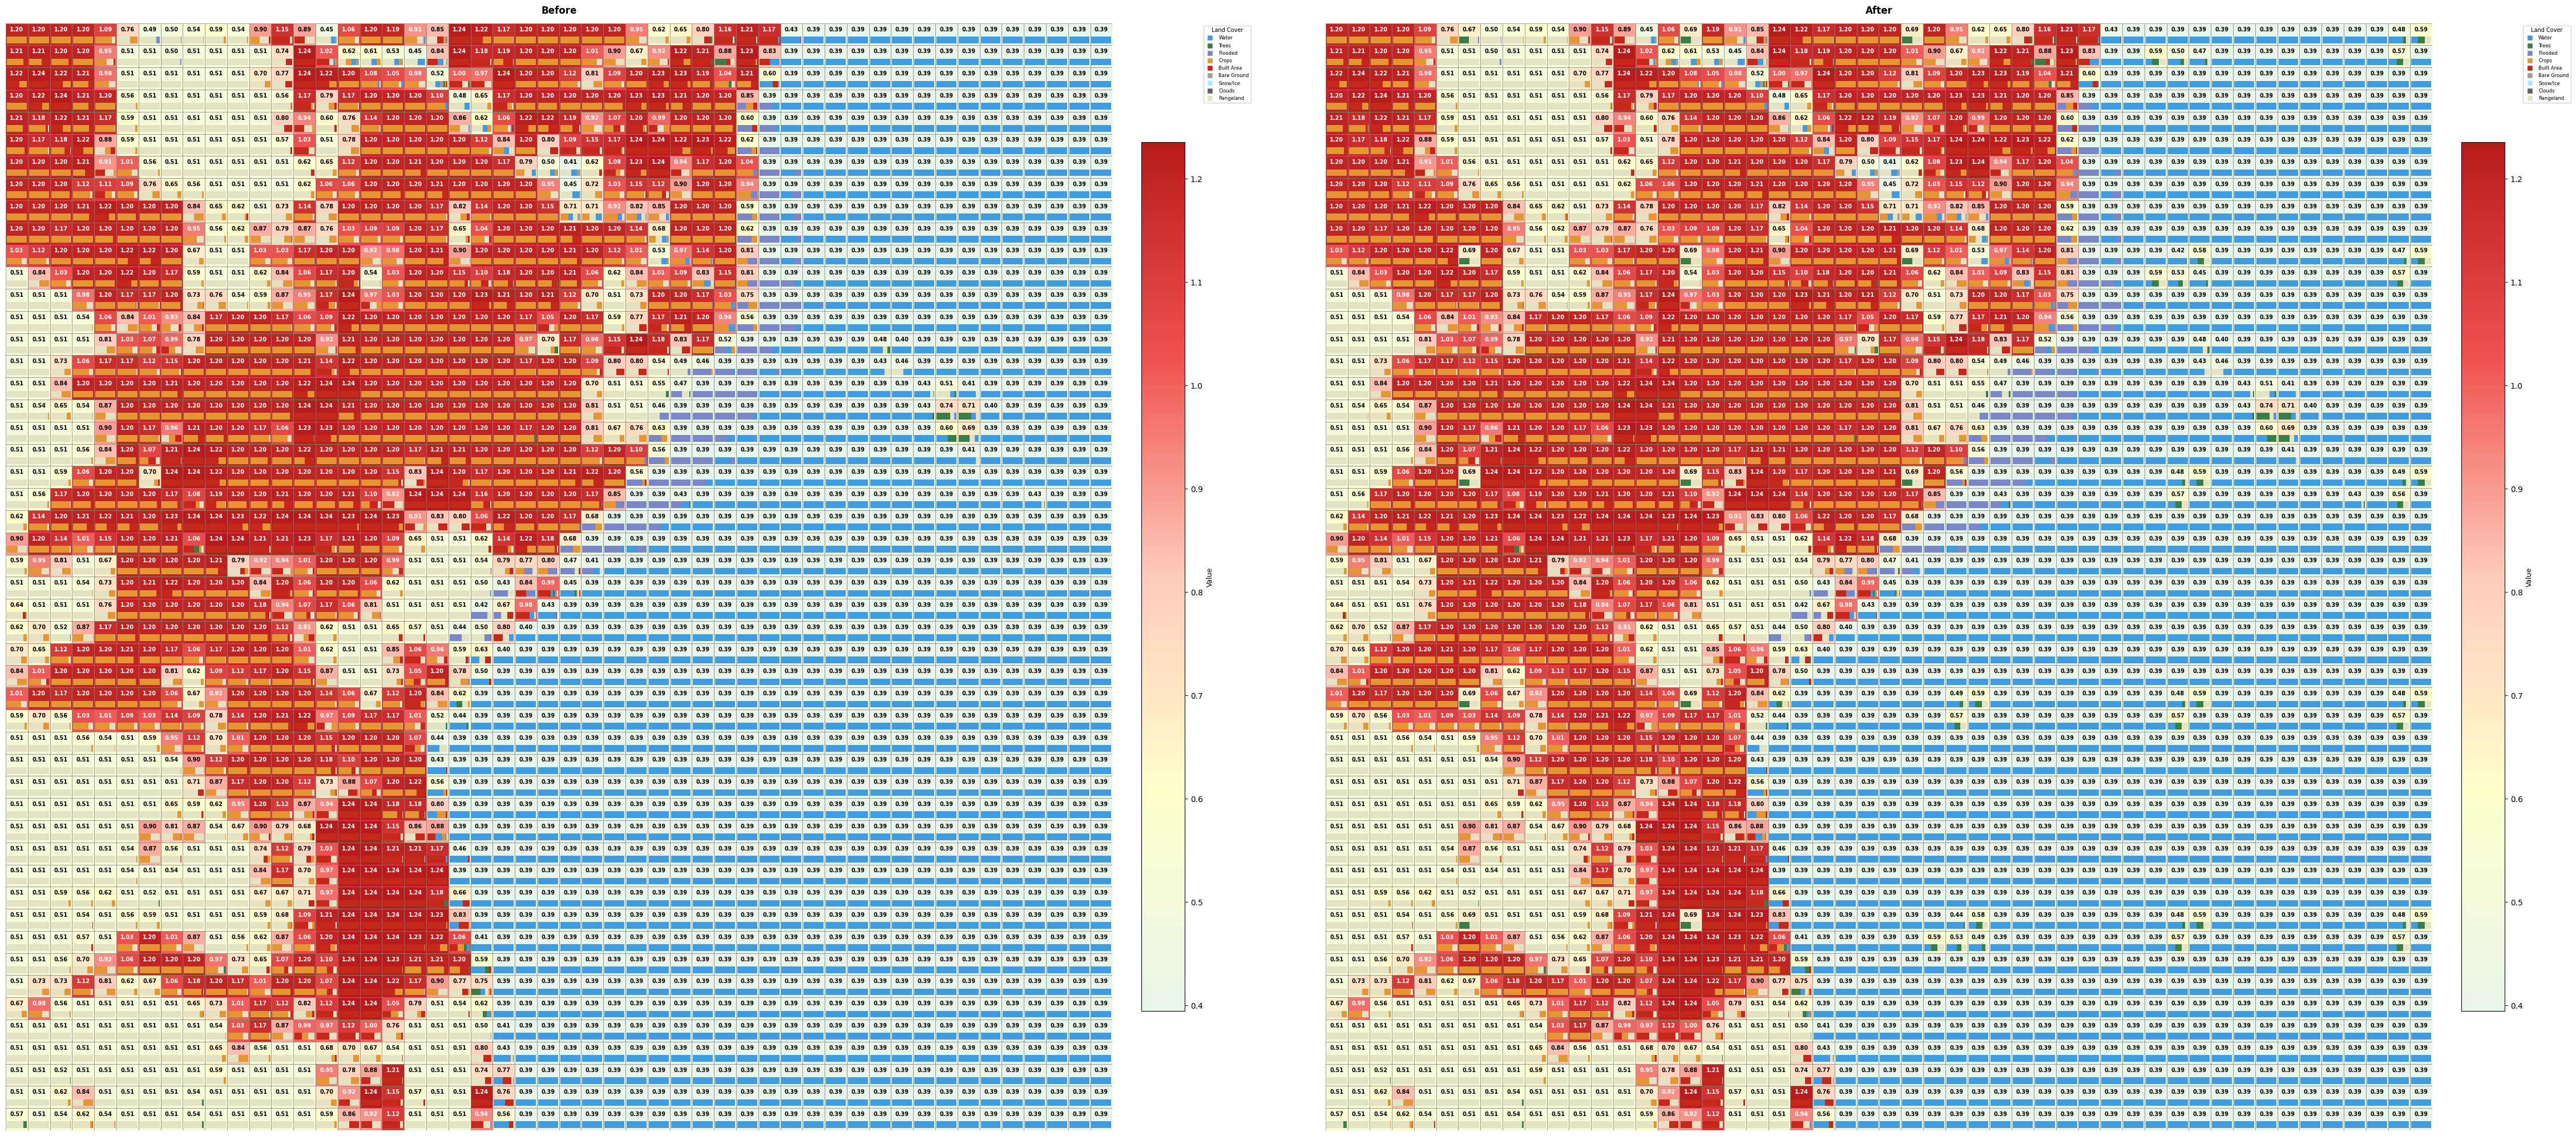

In [31]:
import matplotlib.pyplot as plt
from src.post_eda import plot_state_heatmap

# value_per_class is your ECO_PER_CLASS + ET_PER_CLASS (shape N_CLASSES)
value_vec = ECO_PER_CLASS + ET_PER_CLASS
# # Visualize initial state (obs is shape (10, 10, 12) fractions)
# plot_state_heatmap(obs, value_vec, title="Initial State", unit="Total Value")

# # After model rollout, visualize final state
# plot_state_heatmap(final_obs, value_vec, title="After Policy", unit="Total Value")

# Side-by-side comparison
initial_obs = data['pixel_counts']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(50, 20))
plot_state_heatmap(initial_obs, value_vec, title="Before", ax=ax1)
plot_state_heatmap(final_obs_recst, value_vec, title="After", ax=ax2)
plt.savefig("comparison.png", dpi=200, bbox_inches="tight")


In [32]:
value_vec.shape

(12,)

In [28]:
obs

array([[[0.  , 0.36, 0.28, ..., 0.  , 0.  , 0.28],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        ...,
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ]],

       [[0.  , 0.88, 0.08, ..., 0.  , 0.  , 0.04],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        ...,
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ]],

       [[0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        ...,
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ]],

       ...,

       [[0.  , 0.92, 0. 

In [29]:
info

{'total_value': 38.029200296664236, 'et_increase': 0.0, 'step': 0}

## Actor-Critic Netowrk

In [14]:
from stable_baselines3 import A2C

a2c_config = {
    "policy_type": "MlpPolicy",
    "features_extractor": "GridCNN",
    "features_out": 128,
    "env_name": "LakeMalawiLandUse-v0",
    "algorithm": "A2C",
    "total_timesteps": 500_000,
    "n_steps": 2048,
    "learning_rate": 3e-4,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "ent_coef": 0.02,
    "vf_coef": 0.5,
    "max_grad_norm": 0.5,
    "max_steps": 500,
    "lambda_cont": 0.5,
    "lambda_buf": 0.5,
    "lambda_et": 1.0,
    "reward_scale": 10.0,
}

a2c_policy_kwargs = dict(
    features_extractor_class=GridCNN,
    features_extractor_kwargs=dict(features_out=a2c_config["features_out"]),
)

# initialize WandB
a2c_run = wandb.init(
    project="CS8903-odc",
    config=a2c_config,
    sync_tensorboard=True,
    save_code=True,
)

logger.info("Creating A2C environment …")
a2c_env = LandUseEnv(
    split="train_indices",
    max_steps=a2c_config["max_steps"],
    lambda_cont=a2c_config["lambda_cont"],
    lambda_buf=a2c_config["lambda_buf"],
    lambda_et=a2c_config["lambda_et"],
    reward_scale=a2c_config["reward_scale"],
)

a2c_model = A2C(
    a2c_config["policy_type"],
    a2c_env,
    verbose=1,
    policy_kwargs=a2c_policy_kwargs,
    learning_rate=a2c_config["learning_rate"],
    n_steps=a2c_config["n_steps"],
    gamma=a2c_config["gamma"],
    gae_lambda=a2c_config["gae_lambda"],
    ent_coef=a2c_config["ent_coef"],
    vf_coef=a2c_config["vf_coef"],
    max_grad_norm=a2c_config["max_grad_norm"],
    tensorboard_log=f"runs/{a2c_run.id}",
)

print(a2c_model.policy)

# train
a2c_callbacks = [
    SpatialMetricsCallback(),
    WandbCallback(
        gradient_save_freq=100,
        model_save_path=f"models/{a2c_run.id}",
        verbose=2,
    ),
]

a2c_model.learn(total_timesteps=a2c_config["total_timesteps"], callback=a2c_callbacks, log_interval=1)
a2c_run.finish()


00:13:21 | __main__ | INFO    | Creating A2C environment …


wandb: WARNING When using several event log directories, please call `wandb.tensorboard.patch(root_logdir="...")` before `wandb.init`


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
ActorCriticPolicy(
  (features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (vf_features_extractor): GridCNN(
    (cnn): Sequent

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇█████
rollout/ep_len_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
rollout/ep_rew_mean,▁▂▂▂▆▅▅▆▆▃▂▂▂▂▄▇▇▇▆▇▆▅▅▇▅▃▂▅▇█▅▅▆▅▅▆▅▄▄▄
spatial/buffer_penalty_mean,▅▅▄▂█▄▄▂▄▆▄▂▄▄▃▄▃▃▄▁▄▃▅▂▂▃▂▇▄▂▃▃▃▆▆▅▃▃▃▆
spatial/contiguity_bonus_mean,█▂▂▁▁█▆▂▁▇▂▁▆▁▇▇█▃██▇▁▁▆█▇▁▂█▂▁▁▇▁▂▇▂▁▁▁
time/fps,▁█▇▆▆▅▂▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▆▆▅▅▄▄▄▄▄▄▄▃
train/entropy_loss,▁▄▅▄▄▅▆▅▅▆▆▆▆▆▆▄▅▇▇█▆▆▆▆▆▇▆▇▇▅▅▆▆▆▆▅▇▇█▇
train/explained_variance,█▆█▆▁▇▇▅▇▇██▇▁▇██▆▇▇█▅▇█▅█▇▇▄██▇▇▇█▇▇▇█▇
train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/policy_loss,▁▅▆▄▄▆▄▅█▄▄▅▆▃▅▇▃▇▄▃▅▅▅▄▂▁▇▃▃▇▄▆▅▅▅▅▆▄▆▅
+1,...


## Next Steps
1. Enhance background of project and domain interpretation in web page
2. ~~Refine training - constrain for protected class etc.~~
3. TODO: ~~why loss is negative?~~ what does epochs/max_steps/n_steps mean? ~~how SmallGridCNN integrate with MLP?~~
4. Test all samples
5. Understand how exactly model performs, what the evaluation metrics mean
...
6. Visualize learned policies on real geographical data

## Visualize State

## Playaround

In [70]:
data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
indices = data['train_indices']
indices

array([[10, 30],
       [30, 10],
       [ 0,  0],
       [40, 30],
       [20, 10],
       [10, 40],
       [20, 30],
       [ 0, 10],
       [40, 20],
       [10,  0],
       [ 0, 20],
       [20, 20],
       [30,  0],
       [ 0, 30],
       [ 0, 40],
       [40,  0],
       [30, 20]])

In [71]:
data['pixel_counts'][10:20, 30:40]

array([[[ 0,  5,  0, ...,  0,  0,  1],
        [ 0,  1,  0, ...,  0,  0,  1],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  4],
        [ 0,  7,  0, ...,  0,  0,  2],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  1,  0, ...,  0,  0,  0],
        [ 0,  4,  0, ...,  0,  0,  0],
        ...,
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0]],

       ...,

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0

In [20]:
grid_height = 10
grid_width = 10
num_features = 12
min_value = 0.0
max_value = 25.0

# 2. Define the Box space
# We pass scalar values for low and high, and Gymnasium will automatically 
# expand them to fit the provided shape.
grid_observation_space = Box(
    low=min_value, 
    high=max_value, 
    shape=(grid_height, grid_width, num_features), 
    dtype=int # Use np.int32 if your features are strictly integers
)
state_sample = grid_observation_space.sample()
print(state_sample)
print(state_sample.shape)
# net_values = state_sample * (ECO_PER_CLASS + ET_PER_CLASS)
# net_values
# float(net_values.sum())

[[[13  5  8 ... 24 12  3]
  [ 7  4  3 ... 16 24  2]
  [13 10 13 ...  2 19  9]
  ...
  [ 5 17 10 ...  4  4  0]
  [17 23  5 ... 15  9 22]
  [ 5 11 20 ... 25  8 12]]

 [[14 24  0 ... 18  9 22]
  [21  1  9 ... 19 24  0]
  [13  9 19 ... 19 10  7]
  ...
  [ 2  0  0 ...  3 17  7]
  [23 24 24 ... 16 10  3]
  [11  9 11 ... 21 19 19]]

 [[ 7  2 12 ...  6 18 11]
  [ 4 22 18 ... 23  1 18]
  [11 23  2 ... 15  6 18]
  ...
  [ 6  3 11 ... 20  5 14]
  [24 24 11 ...  5 11 25]
  [16 23  8 ...  2  9  0]]

 ...

 [[24  8 17 ... 17 17  5]
  [13  4  2 ... 10 10 19]
  [ 5  4  9 ...  4 11  5]
  ...
  [12 18 20 ...  0 18 25]
  [ 8 10  5 ...  1 20 16]
  [16 16  2 ...  6 19 16]]

 [[ 0 17  1 ...  1 17 16]
  [18 18 14 ...  2 20 10]
  [ 4  2 17 ... 21 12 14]
  ...
  [ 6 21 10 ... 13 13  4]
  [23 24 11 ... 21  5  2]
  [25 13 22 ...  6  5  7]]

 [[ 6 21 11 ...  5 13  9]
  [ 0 21  3 ...  3  8 11]
  [ 0 16  2 ...  2  4  2]
  ...
  [19  8 17 ... 19  1  0]
  [22  1  5 ... 16  1 15]
  [20  8 21 ... 10 24  8]]]
(10, 10, 1

In [47]:
grid_observation_space.shape

(10, 10, 12)

In [46]:
print(state_sample[6, 4, :])
print(state_sample[6, 4, :] + action_sample['delta_s'])

[ 2 25  4  5  5 25 24 24 20 11 25 11]
[ 11  14 -19  16 -15  30  28  37  11 -14  46  -9]


In [52]:
action_space = Dict({
    # select the (i, j) cell
    "cell_coords": MultiDiscrete([size, size]), 
    # delta change for the 12 land-use types
    "delta_s": Box(low=-1, high=1, shape=(N_CLASSES,), dtype=int)
})
action_sample = action_space.sample()
action_sample

{'cell_coords': array([4, 4]),
 'delta_s': array([-1,  1,  0,  0, -1,  1,  1,  1,  1,  0,  1, -1])}

In [45]:
cell_coords = action_sample['cell_coords']
state_sample[cell_coords[0], cell_coords[1], :]

array([ 2, 25,  4,  5,  5, 25, 24, 24, 20, 11, 25, 11])